<a href="https://colab.research.google.com/github/Safae-s/TP3-ML-Master/blob/main/TP3_ML_AppNonSup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importation des biblioheques**

In [ ]:
#les bib pour manipulation des donnes
import pandas as pd
import numpy as np
#les bib pour visualisation:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#dataset Iris
from sklearn.datasets import load_iris
#pretraitement:
from sklearn.preprocessing import StandardScaler
#Reduction de dimension:
from sklearn.decomposition import PCA
#les Algos de clustring:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#Evaluation:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
#hdbscan--> bonnus
import hdbscan


**Chargement de dataser**

In [ ]:
#Charger datase Iris
iris =load_iris()
X=iris.data
y= iris.target
#Convertire en  dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
#Affichagee les 5 premiers et dernieres lignes:
print("les 5 premiers lignes:\n", df.head())
print("\nLes 5 dernieres lignes:\n", df.tail())


les 5 premiers lignes:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Les 5 dernieres lignes:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8


In [ ]:
print("-les types:\n",df.dtypes)
print("\n-les colonnes:\n",df.columns)
print("\n-Les statistiques:", df.describe())

-les types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

-les colonnes:
 Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

-Les statistiques:        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min        

**Histogramme**

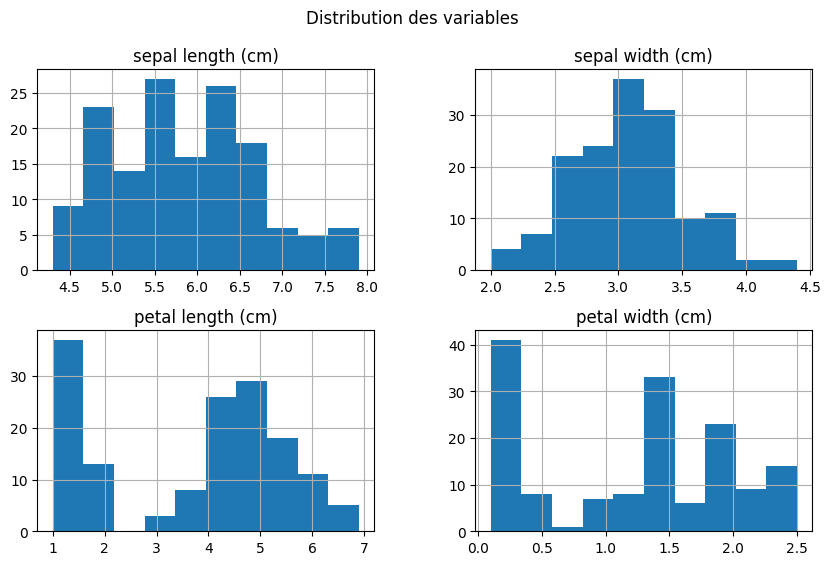

In [ ]:
#Histogramme des variables:
df.hist(figsize=(10,6))
plt.suptitle("Distribution des variables")
plt.show()


**Boxplots**

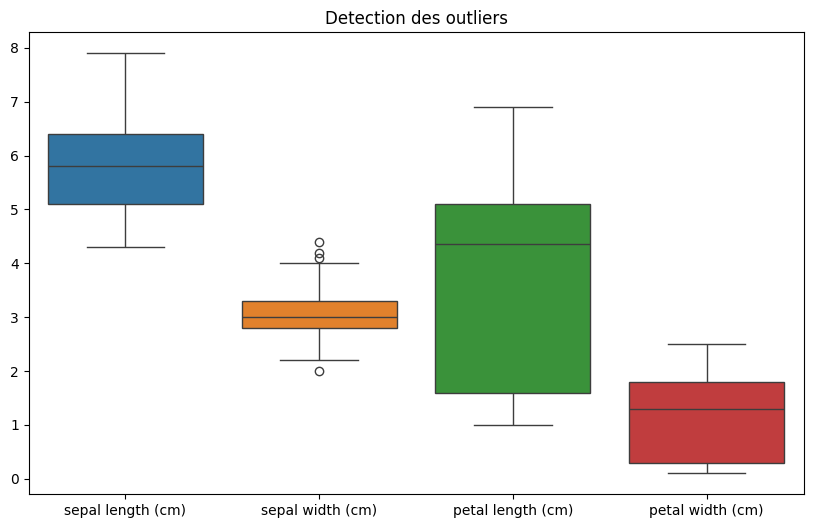

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Detection des outliers")
plt.show()


**Matrice de correlation:**

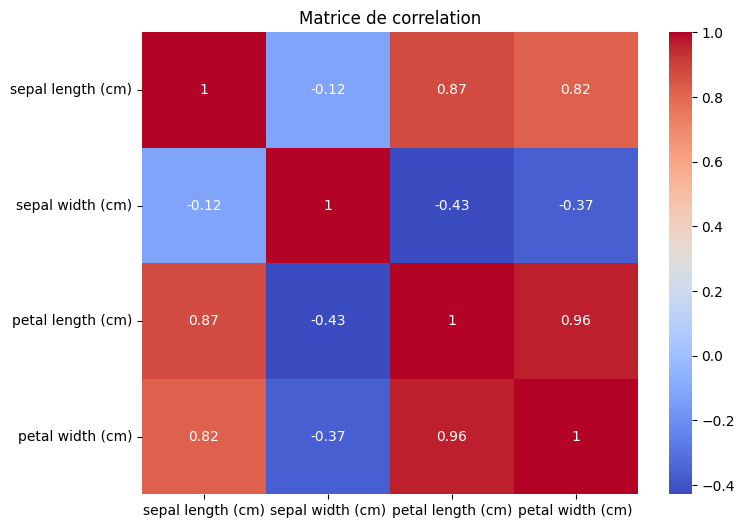

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de correlation")
plt.show()


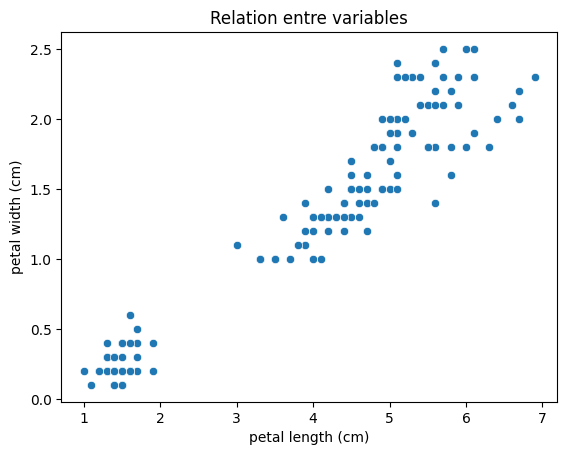

In [ ]:
sns.scatterplot(x=df.iloc[:,2], y=df.iloc[:,3])
plt.title("Relation entre variables")
plt.show()

In [ ]:
#valeur manquantes:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


**Standarisation::**

In [ ]:
#moyenne=0 , variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Reduction de dimension-PCA-**

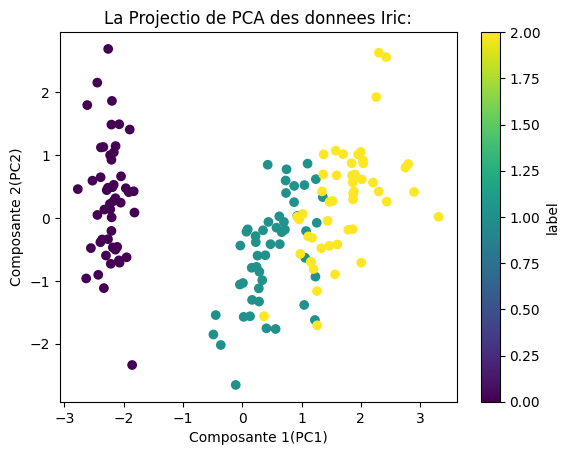

In [ ]:

#Reduire à 2 Dimension pour visualisation:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Visualisation des donnes
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("La Projectio de PCA des donnees Iric:")
plt.xlabel("Composante 1(PC1)")
plt.ylabel("Composante 2(PC2)")
plt.colorbar(label='label')
plt.show()

In [ ]:
variance_ratio = pca.explained_variance_ratio_
# Conversion en pourcentage
pca1 = variance_ratio[0] * 100
pca2 = variance_ratio[1] * 100
total = (variance_ratio[0] + variance_ratio[1]) * 100
tableau_pca = pd.DataFrame({
    "Composante principale": ["PCA 1", "PCA 2", "Variance totale"],
    "Variance expliquée (%)": [
        round(pca1, 2),
        round(pca2, 2),
        round(total, 2)
    ]
})
print("Tableau III : Variance expliquée par les composantes principales\n")
print(tableau_pca)


Tableau III : Variance expliquée par les composantes principales

  Composante principale  Variance expliquée (%)
0                 PCA 1                   72.96
1                 PCA 2                   22.85
2       Variance totale                   95.81


**k-Means**

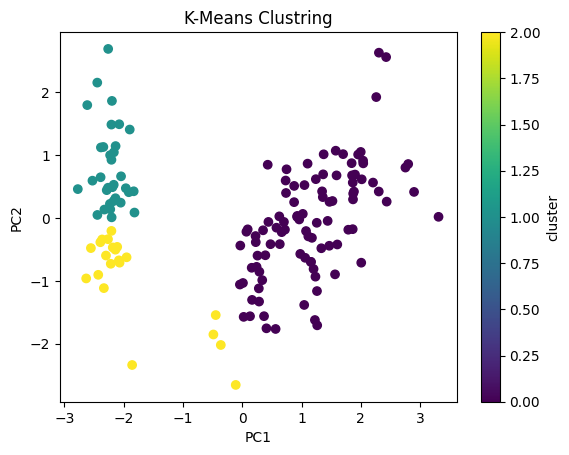

In [ ]:
KMeans = KMeans(n_clusters=3, random_state=42)
labels_Kmeans = KMeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_Kmeans)
plt.title("K-Means Clustring")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='cluster')
plt.show()


**DBSCAN**

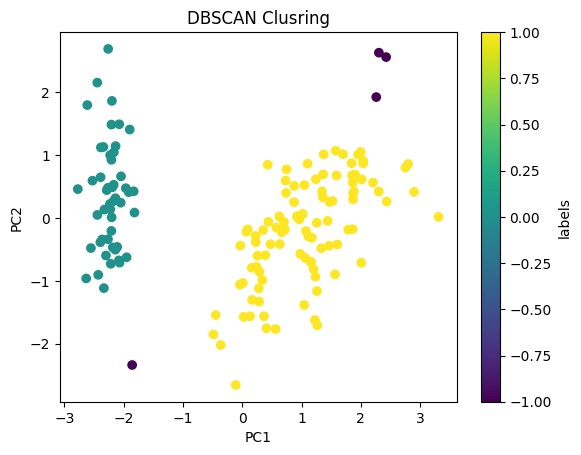

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan)
plt.title("DBSCAN Clusring")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="labels")
plt.show()


**Agglomerative Clustering**:

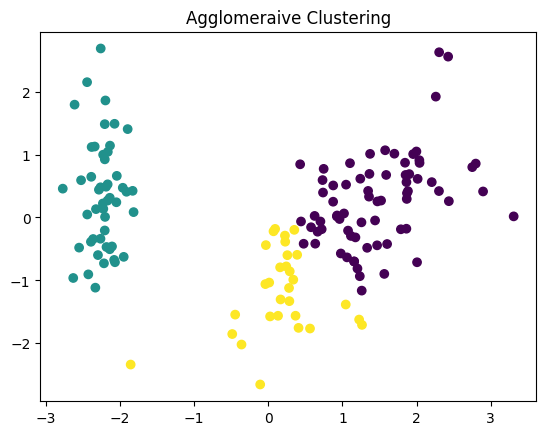

In [ ]:
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg)
plt.title("Agglomeraive Clustering")
plt.show()


**Bonus-HDBSCAN**

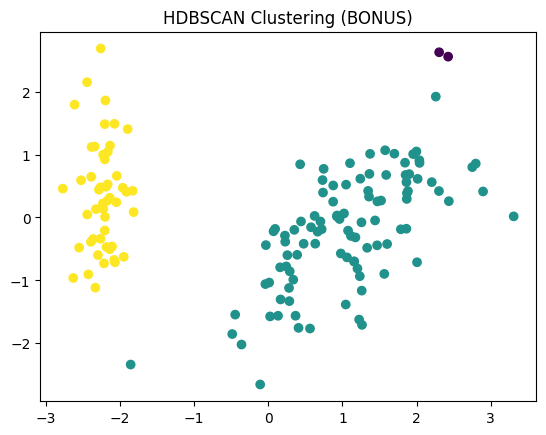

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels_hdbscan = clusterer.fit_predict(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_hdbscan)
plt.title("HDBSCAN Clustering (BONUS)")
plt.show()

**Evaluation des modèles:**

In [ ]:
def evaluate(X,labels, name):
  if len(set(labels))>1:
    print(name)
    print("Sihouette:", silhouette_score(X, labels))
    print("Davies_Bouldin:", davies_bouldin_score(X, labels))
    print("Calinski-harabasz:", calinski_harabasz_score(X,labels))
    print("-"*40)

evaluate(X_scaled, labels_Kmeans,"KMeans")
evaluate(X_scaled, labels_dbscan, "DBSCAN")
evaluate(X_scaled, labels_agg,"Agglomerative")
evaluate(X_scaled, labels_hdbscan, "HDBSCAN")


KMeans
Sihouette: 0.4798814508199817
Davies_Bouldin: 0.7893630242997912
Calinski-harabasz: 157.36015312192248
----------------------------------------
DBSCAN
Sihouette: 0.5216965052515835
Davies_Bouldin: 1.9432005358011466
Calinski-harabasz: 126.22116557281582
----------------------------------------
Agglomerative
Sihouette: 0.4466890410285909
Davies_Bouldin: 0.8034665302876753
Calinski-harabasz: 222.71916382215363
----------------------------------------
HDBSCAN
Sihouette: 0.48911755205309493
Davies_Bouldin: 0.5345432385289371
Calinski-harabasz: 136.98980109797395
----------------------------------------
